<a href="https://colab.research.google.com/github/varshithdharmaj/dbsacn/blob/main/parkinsons_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving parkinsons.data to parkinsons (1).data
Saving parkinsons.names to parkinsons (1).names


In [4]:
import pandas as pd

df = pd.read_csv('/content/parkinsons.data')
df.head()


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
df.shape
df.info()
df.describe()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [6]:
X = df.drop(columns=['name', 'status'])
y = df['status']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8974358974358975
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



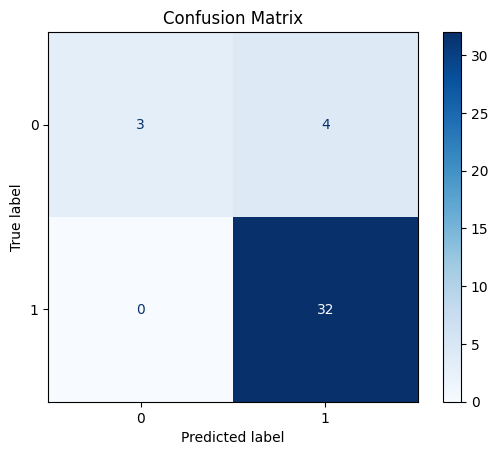

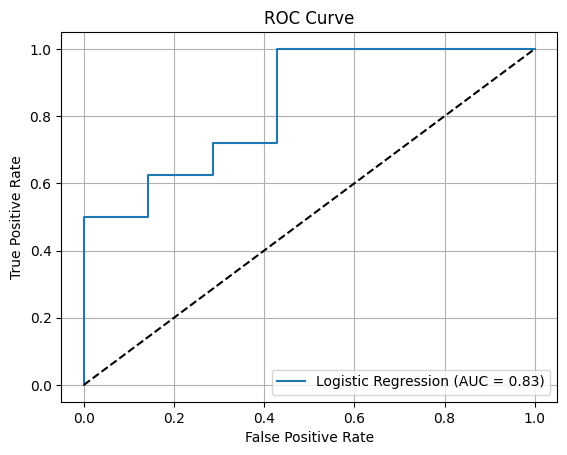

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



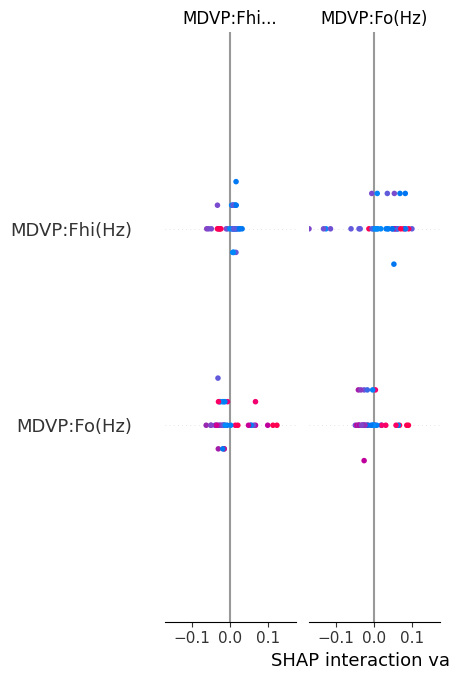

In [11]:
!pip install shap

import shap
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, features=X_test, feature_names=X.columns)


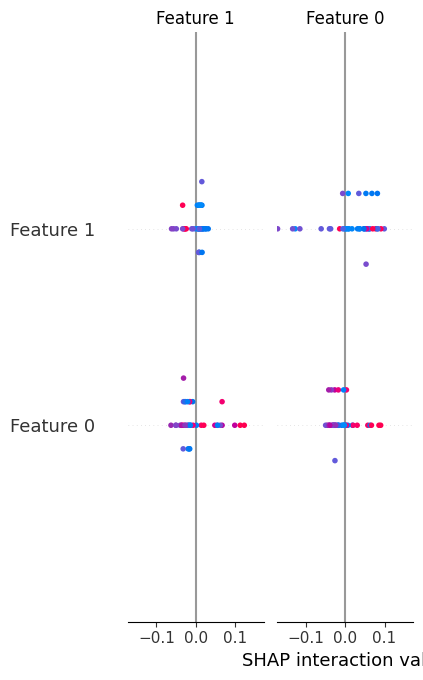

In [12]:
import shap
import matplotlib.pyplot as plt

# Assuming you already used shap.TreeExplainer and have 'shap_values'
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [14]:
pip install streamlit shap matplotlib scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00


In [16]:
app_code = """
import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open('parkinson_model.pkl', 'rb'))

st.title("🧠 Parkinson’s Disease Detection")
st.write("Upload patient's voice test data to detect Parkinson’s")

# Input fields for relevant features
fo = st.number_input("MDVP:Fo(Hz)", min_value=0.0, step=0.1)
fhi = st.number_input("MDVP:Fhi(Hz)", min_value=0.0, step=0.1)
flo = st.number_input("MDVP:Flo(Hz)", min_value=0.0, step=0.1)
jitter_percent = st.number_input("MDVP:Jitter(%)", min_value=0.0, step=0.001)
rap = st.number_input("MDVP:RAP", min_value=0.0, step=0.001)
ppe = st.number_input("PPE", min_value=0.0, step=0.001)

# Collect input
input_data = np.array([[fo, fhi, flo, jitter_percent, rap, ppe]])

# Predict
if st.button("Predict"):
    prediction = model.predict(input_data)
    if prediction[0] == 1:
        st.error("⚠️ The patient is likely to have Parkinson’s disease.")
    else:
        st.success("✅ The patient is unlikely to have Parkinson’s disease.")
"""

# Save the file
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created")


✅ app.py created


In [17]:
import pickle

# Replace with your actual model object
pickle.dump(model, open("parkinson_model.pkl", "wb"))


In [18]:
from google.colab import files

files.download("app.py")
files.download("parkinson_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Define the Streamlit app code
streamlit_code = """
import streamlit as st
import numpy as np
import pickle

# Load the trained model
model = pickle.load(open('parkinson_model.pkl', 'rb'))

st.set_page_config(page_title="Parkinson's Disease Detection", page_icon="🧠")
st.title("🧠 Parkinson’s Disease Detection App")

st.markdown("Upload voice features to detect Parkinson’s Disease.")

# Input fields (add more if needed)
fo = st.number_input("MDVP:Fo(Hz)", min_value=0.0, step=0.1)
fhi = st.number_input("MDVP:Fhi(Hz)", min_value=0.0, step=0.1)
flo = st.number_input("MDVP:Flo(Hz)", min_value=0.0, step=0.1)
jitter_percent = st.number_input("MDVP:Jitter(%)", min_value=0.0, step=0.001)
rap = st.number_input("MDVP:RAP", min_value=0.0, step=0.001)
ppe = st.number_input("PPE", min_value=0.0, step=0.001)

# Prepare input for prediction
input_data = np.array([[fo, fhi, flo, jitter_percent, rap, ppe]])

# Predict
if st.button("Predict"):
    prediction = model.predict(input_data)
    if prediction[0] == 1:
        st.error("⚠️ The patient is likely to have Parkinson’s Disease.")
    else:
        st.success("✅ The patient is unlikely to have Parkinson’s Disease.")
"""

# Save it as streamlit_app.py
with open("streamlit_app.py", "w") as f:
    f.write(streamlit_code)

print("✅ streamlit_app.py has been created!")


✅ streamlit_app.py has been created!


In [20]:
from google.colab import files
files.download("streamlit_app.py")
files.download("parkinson_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
print("Expected number of input features:", model.n_features_in_)


Expected number of input features: 22


In [24]:
st.title("🧠 Parkinson’s Disease Prediction")

# Example: Collect 22 features
input_features = []
feature_names = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)',
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)',
    'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR',
    'HNR', 'RPDE', 'DFA', 'spread1', 'spread2',
    'D2', 'PPE'
]

for name in feature_names:
    value = st.number_input(name, step=0.001, format="%.6f")
    input_features.append(value)

input_data = np.array([input_features])


2025-07-02 22:52:02.856 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:02.927 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-07-02 22:52:02.928 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:02.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:02.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:02.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:02.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:02.935 Thread 'MainThread': mi

In [25]:
if st.button("Predict"):
    if scaler_loaded:
        input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)
    if prediction[0] == 1:
        st.error("⚠️ Parkinson's likely")
    else:
        st.success("✅ Parkinson's unlikely")


2025-07-02 22:52:22.356 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:22.357 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:22.358 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:22.359 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:22.360 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:22.361 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [26]:
proba = model.predict_proba(input_data)[0]
st.write(f"Probability of Parkinson's: {proba[1]:.2%}")


2025-07-02 22:52:51.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:51.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-02 22:52:51.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X = training features


In [28]:
import pickle
from sklearn.preprocessing import StandardScaler

# Assume X is your feature DataFrame
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the model too
with open('parkinson_model.pkl', 'wb') as f:
    pickle.dump(model, f)


In [29]:
!pip install streamlit pyngrok pytesseract pillow
!apt-get install -y tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [30]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import os
import pytesseract
from PIL import Image
import re

# Load the model and scaler
MODEL_PATH = 'parkinson_model.pkl'
SCALER_PATH = 'scaler.pkl'

with open(MODEL_PATH, 'rb') as file:
    model = pickle.load(file)

if os.path.exists(SCALER_PATH):
    with open(SCALER_PATH, 'rb') as s:
        scaler = pickle.load(s)
    scaler_loaded = True
else:
    scaler_loaded = False

# Feature list (used while training)
feature_names = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)',
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)',
    'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR',
    'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE'
]

# Streamlit UI
st.set_page_config(page_title="Parkinson's Prediction", layout="centered")
st.title("🧠 Parkinson’s Disease Prediction")
st.markdown("Choose how you want to input the data:")

# Select input mode
input_mode = st.radio("Select Input Method", [
    "Manual Entry", "CSV Upload", "Paste Values", "Upload Screenshot (OCR Extraction)"
])

input_data = None

if input_mode == "Manual Entry":
    input_features = []
    for name in feature_names:
        value = st.number_input(name, step=0.001, format="%.6f")
        input_features.append(value)
    input_data = np.array([input_features])

elif input_mode == "CSV Upload":
    uploaded_file = st.file_uploader("Upload a CSV file with 1 row and 22 columns", type=["csv"])
    if uploaded_file is not None:
        try:
            df = pd.read_csv(uploaded_file)
            if df.shape[1] != 22:
                st.error("CSV must contain exactly 22 columns.")
            else:
                input_data = df.values
        except Exception as e:
            st.error(f"Error reading CSV: {e}")

elif input_mode == "Paste Values":
    text_input = st.text_area("Paste 22 comma-separated values", height=100)
    if text_input:
        try:
            values = [float(x.strip()) for x in text_input.split(",")]
            if len(values) != 22:
                st.error("You must enter exactly 22 values.")
            else:
                input_data = np.array([values])
        except ValueError:
            st.error("Please ensure all values are numeric and comma-separated.")

elif input_mode == "Upload Screenshot (OCR Extraction)":
    uploaded_image = st.file_uploader("Upload Image (PNG or JPG)", type=["png", "jpg", "jpeg"])

    if uploaded_image is not None:
        image = Image.open(uploaded_image)
        st.image(image, caption="Uploaded Screenshot", use_column_width=True)

        extracted_text = pytesseract.image_to_string(image)
        st.text_area("🔍 OCR Extracted Text", extracted_text, height=150)

        numbers = re.findall(r"[-+]?\d*\.\d+|\d+", extracted_text)
        values = list(map(float, numbers))

        if len(values) < 22:
            st.error("❌ Could not extract 22 numerical values. Try a clearer image.")
        elif len(values) > 22:
            st.warning("⚠️ More than 22 values found. Using the first 22.")
            values = values[:22]
            input_data = np.array([values])
        else:
            st.success("✅ Successfully extracted 22 values from image.")
            input_data = np.array([values])

# Predict if data is ready
if input_data is not None and st.button("Predict"):
    if scaler_loaded:
        input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)[0][1]

    if prediction[0] == 1:
        st.error(f"⚠️ Likely Parkinson's Disease Detected. Probability: {probability:.2%}")
    else:
        st.success(f"✅ Unlikely to have Parkinson's Disease. Probability: {probability:.2%}")


Overwriting app.py


In [32]:
!pip install pyngrok


In [33]:
from pyngrok import ngrok

ngrok.set_auth_token("2zL9N6un4EzXFxh4lYeOscljIE3_57RhQCJs85ScVorLddPSg")


In [34]:
!streamlit run app.py &>/content/logs.txt &


In [35]:
%%writefile app.py
# Paste your entire Streamlit code below this line
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import os

# Load the model
MODEL_PATH = 'parkinson_model.pkl'
SCALER_PATH = 'scaler.pkl'

with open(MODEL_PATH, 'rb') as file:
    model = pickle.load(file)

# Load scaler if used
if os.path.exists(SCALER_PATH):
    with open(SCALER_PATH, 'rb') as s:
        scaler = pickle.load(s)
    scaler_loaded = True
else:
    scaler_loaded = False

feature_names = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)',
    'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)',
    'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR',
    'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE'
]

st.set_page_config(page_title="Parkinson's Prediction", layout="centered")
st.title("🧠 Parkinson’s Disease Prediction")
st.markdown("Choose how you want to input the data:")

input_mode = st.radio("Select Input Method", ["Manual Entry", "CSV Upload", "Paste Values"])

input_data = None

if input_mode == "Manual Entry":
    input_features = []
    for name in feature_names:
        value = st.number_input(name, step=0.001, format="%.6f")
        input_features.append(value)
    input_data = np.array([input_features])

elif input_mode == "CSV Upload":
    uploaded_file = st.file_uploader("Upload a CSV file with 1 row and 22 columns", type=["csv"])
    if uploaded_file is not None:
        try:
            df = pd.read_csv(uploaded_file)
            if df.shape[1] != 22:
                st.error("CSV must contain exactly 22 columns.")
            else:
                input_data = df.values
        except Exception as e:
            st.error(f"Error reading CSV: {e}")

elif input_mode == "Paste Values":
    text_input = st.text_area("Paste 22 comma-separated values", height=100)
    if text_input:
        try:
            values = [float(x.strip()) for x in text_input.split(",")]
            if len(values) != 22:
                st.error("You must enter exactly 22 values.")
            else:
                input_data = np.array([values])
        except ValueError:
            st.error("Please ensure all values are numeric and comma-separated.")

if input_data is not None and st.button("Predict"):
    if scaler_loaded:
        input_data = scaler.transform(input_data)

    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)[0][1]

    if prediction[0] == 1:
        st.error(f"⚠️ Likely Parkinson's Disease Detected. Probability: {probability:.2%}")
    else:
        st.success(f"✅ Unlikely to have Parkinson's Disease. Probability: {probability:.2%}")


Overwriting app.py


In [39]:
!pip install easyocr opencv-python-headless plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [40]:
!streamlit run app.py &>/content/logs.txt &


In [41]:
from pyngrok import ngrok

public_url = ngrok.connect(addr="8501")

print("🌐 Your App is live at:", public_url)


🌐 Your App is live at: NgrokTunnel: "https://b234-34-145-204-64.ngrok-free.app" -> "http://localhost:8501"


In [44]:
!npm install -g localtunnel


^C


In [45]:
!streamlit run app.py & npx localtunnel --port 8501


⠙⠹

⠸⠼⠴⠦
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.145.204.64:8501

⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼your url is: https://lovely-hoops-tap.loca.lt
  Stopping...
^C


In [47]:
!streamlit run app.py & ngrok http 8501





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.145.204.64:8501

  Stopping...
Traceback (most recent call last):
  File "/usr/local/bin/ngrok", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pyngrok/ngrok.py", line 687, in main
    run(sys.argv[1:])
  File "/usr/local/lib/python3.11/dist-packages/pyngrok/ngrok.py", line 675, in run
    process.run_process(pyngrok_config.ngrok_path, args)
  File "/usr/local/lib/python3.11/dist-packages/pyngrok/process.py", line 312, in run_process
    subprocess.call(start)
  File "/usr/lib/python3.11/subprocess.py", line 391, in call
    return p.wait(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 1264, in wait
    return self._wait(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py

In [51]:
# Cell in Colab (Python)
import subprocess
import time

# Start Streamlit
streamlit_process = subprocess.Popen(["streamlit", "run", "app.py"])

# Wait a bit for streamlit to start
time.sleep(5)

# Start ngrok
!ngrok config add-authtoken 2zL9N6un4EzXFxh4lYeOscljIE3_57RhQCJs85ScVorLddPSg
!ngrok http 8501


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Traceback (most recent call last):
  File "/usr/local/bin/ngrok", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pyngrok/ngrok.py", line 687, in main
    run(sys.argv[1:])
  File "/usr/local/lib/python3.11/dist-packages/pyngrok/ngrok.py", line 675, in run
    process.run_process(pyngrok_config.ngrok_path, args)
  File "/usr/local/lib/python3.11/dist-packages/pyngrok/process.py", line 312, in run_process
    subprocess.call(start)
  File "/usr/lib/python3.11/subprocess.py", line 391, in call
    return p.wait(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 1264, in wait
    return self._wait(timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 2053, in _wait
    (pid, sts) = self._try_wait(0)
                 ^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/

In [52]:
streamlit run app.py
# or
streamlit run streamlit_app.py


SyntaxError: invalid syntax (ipython-input-52-2888583842.py, line 1)

In [56]:
import pickle
from sklearn.ensemble import RandomForestClassifier

# Load your dataset
import pandas as pd
df = pd.read_csv("parkinsons.data")
y = df['status']

# 6-feature model
X6 = df[['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:RAP', 'PPE']]
model6 = RandomForestClassifier().fit(X6, y)
pickle.dump(model6, open("parkinson_model_6.pkl", "wb"))

# 22-feature model
X22 = df.drop(columns=['name', 'status'])
model22 = RandomForestClassifier().fit(X22, y)
pickle.dump(model22, open("parkinson_model_22.pkl", "wb"))


In [59]:
import pickle

with open("scaler_6.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [62]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler

# Load the original dataset
df = pd.read_csv("parkinsons.data")

# Rename columns to match model input
df = df.rename(columns={
    'MDVP:Fo(Hz)': 'fo',
    'MDVP:Fhi(Hz)': 'fhi',
    'MDVP:Flo(Hz)': 'flo',
    'MDVP:Jitter(%)': 'jitter_percent',
    'MDVP:RAP': 'rap',
    'PPE': 'ppe'
})

# Now extract the required 6 features
features_6 = ['fo', 'fhi', 'flo', 'jitter_percent', 'rap', 'ppe']
X = df[features_6]

# Fit the scaler
scaler = StandardScaler()
scaler.fit(X)

# Save the scaler
with open("scaler_6.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ scaler_6.pkl saved successfully.")


✅ scaler_6.pkl saved successfully.


In [64]:
!python generate_scaler.py


python3: can't open file '/content/generate_scaler.py': [Errno 2] No such file or directory


In [65]:
code = """
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler

# Load the dataset (adjust path if needed)
df = pd.read_csv("parkinsons_data.csv")  # Make sure this file is uploaded!

# 6-feature set
features_6 = ['fo', 'fhi', 'flo', 'jitter_percent', 'rap', 'ppe']
scaler_6 = StandardScaler()
scaler_6.fit(df[features_6])
with open("scaler_6.pkl", "wb") as f:
    pickle.dump(scaler_6, f)

# 22-feature set
features_22 = features_6 + [f'feature_{i}' for i in range(7, 23)]
scaler_22 = StandardScaler()
scaler_22.fit(df[features_22])
with open("scaler_22.pkl", "wb") as f:
    pickle.dump(scaler_22, f)

print("✅ Scalers saved as 'scaler_6.pkl' and 'scaler_22.pkl'")
"""
with open("generate_scaler.py", "w") as f:
    f.write(code)
print("✅ generate_scaler.py created.")


✅ generate_scaler.py created.


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("parkinsons_data.csv")  # Now it should work

features_6 = ['fo', 'fhi', 'flo', 'jitter_percent', 'rap', 'ppe']
scaler_6 = StandardScaler()
scaler_6.fit(df[features_6])
with open("scaler_6.pkl", "wb") as f:
    pickle.dump(scaler_6, f)

features_22 = features_6 + [f'feature_{i}' for i in range(7, 23)]
scaler_22 = StandardScaler()
scaler_22.fit(df[features_22])
with open("scaler_22.pkl", "wb") as f:
    pickle.dump(scaler_22, f)

print("✅ Scalers saved successfully.")


In [ ]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Example: assuming df_6 contains the 6 relevant columns
X = df_6.drop("status", axis=1)
y = df_6["status"]

scaler_6 = StandardScaler()
X_scaled = scaler_6.fit_transform(X)

model_6 = RandomForestClassifier()
model_6.fit(X_scaled, y)

# Save the scaler and model
pickle.dump(scaler_6, open("scaler_6.pkl", "wb"))
pickle.dump(model_6, open("model_6.pkl", "wb"))
